In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler,MinMaxScaler
from sklearn.cluster import KMeans
import time
from sklearn.model_selection import train_test_split,StratifiedKFold,GridSearchCV
from sklearn.metrics import classification_report , confusion_matrix ,f1_score,accuracy_score
from imblearn.over_sampling import SMOTENC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier,AdaBoostClassifier , RandomForestClassifier , StackingClassifier,ExtraTreesClassifier,GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import RFE
import scipy.stats as stats
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
# import squarify

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('dataIBM.csv', delimiter=';')

In [3]:
# Additional imports for the EDA visualisations
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.facecolor"] = "white"


## Data Exploration

### Basic Exploration

Check the columns, dtypes and dimensions.

In [4]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

**Structure du dataset :**

- **1 470 lignes × 35 colonnes**
- **26 variables numériques** (int64) et **9 variables catégorielles** (object)
- **0 valeur manquante** → pas d'imputation nécessaire
- La cible `Attrition` est binaire (`Yes` / `No`) → **problème de classification binaire**
- `EmployeeNumber` est un identifiant → à exclure de la modélisation


### Statistical Exploration

In [6]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [7]:
df.describe(include=['O'])

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


**Observations statistiques :**

- Les *rate variables* (`DailyRate`, `HourlyRate`, `MonthlyRate`) sont presque **uniformément distribuées** (skew ≈ 0) → leur pouvoir discriminant est probablement faible.
- `MonthlyIncome` va de **1 009 à 19 999** avec une médiane à **4 919** → forte dispersion des salaires.
- `Age` varie de **18 à 60 ans**, moyenne ≈ 37 → population jeune-mature.
- Les variables ordinales de satisfaction (échelle 1→4) ont une médiane à 3.


**Colonnes à supprimer avant modélisation (aucun pouvoir prédictif) :**

- `EmployeeCount` = 1 (constante)
- `Over18` = 'Y' (constante)
- `StandardHours` = 80 (constante)
- `EmployeeNumber` (identifiant unique)


In [8]:
# Skewness of numerical features
df.skew(numeric_only=True).sort_values(ascending=False)

,0
YearsSinceLastPromotion,1.984290
PerformanceRating,1.921883
YearsAtCompany,1.764529
MonthlyIncome,1.369817
TotalWorkingYears,1.117172
NumCompaniesWorked,1.026471
JobLevel,1.025401
StockOptionLevel,0.968980
DistanceFromHome,0.958118
YearsInCurrentRole,0.917363


**Interprétation de la skewness :**

- **Fortement asymétriques à droite** (skew > 1) : `YearsSinceLastPromotion` (1.98), `PerformanceRating` (1.92), `YearsAtCompany` (1.76), `MonthlyIncome` (1.37), `TotalWorkingYears` (1.12), `NumCompaniesWorked` (1.03), `JobLevel` (1.03) → une **transformation log** peut aider pour les modèles linéaires (inutile pour Random Forest / XGBoost).
- **Modérément asymétriques à gauche** : `WorkLifeBalance` (-0.55), `JobInvolvement` (-0.50) → la majorité des employés se déclare plutôt satisfaite.
- **Proches d'une uniforme** (|skew| < 0.05) : `DailyRate`, `HourlyRate`, `MonthlyRate` → **pas de signal exploitable** dans ces variables.
- `EmployeeNumber`, `StandardHours`, `EmployeeCount` : ID ou constantes → à retirer.


#### Missing Values

In [9]:
df.isnull().sum().sum()

np.int64(0)

- No missing values to handle.

---

## Visual Exploratory Data Analysis

Now let's dive into the visual EDA to uncover patterns behind employee attrition.

### EDA 1 — Target Distribution (Attrition)

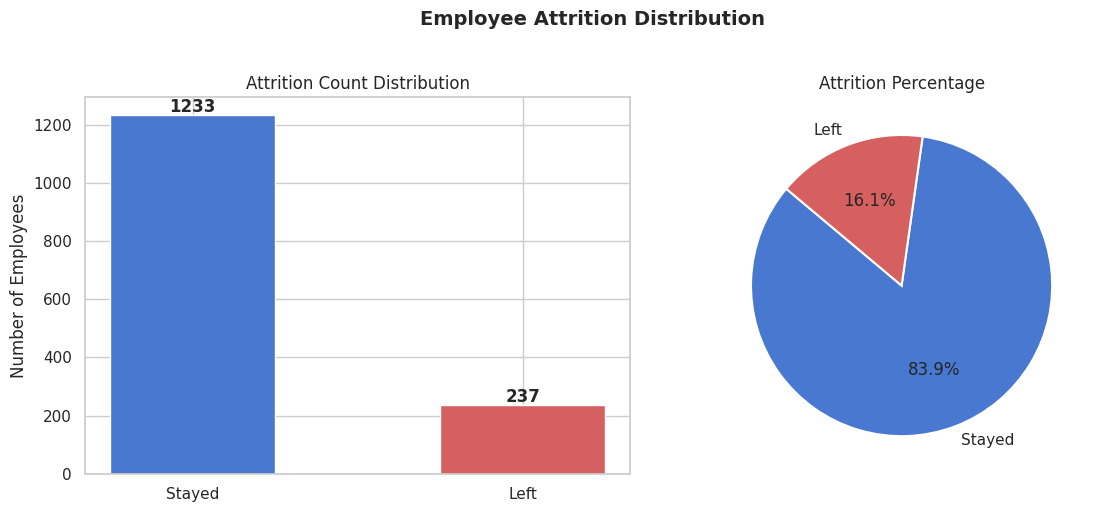

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ["Stayed", "Left"]
counts = df["Attrition"].value_counts()
# Ensure order: No first, Yes second
counts = counts.reindex(["No", "Yes"])
colors = ["#4878CF", "#D65F5F"]

axes[0].bar(labels, counts.values, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Attrition Count Distribution")
axes[0].set_ylabel("Number of Employees")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

axes[1].pie(
    counts.values,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[1].set_title("Attrition Percentage")

plt.suptitle("Employee Attrition Distribution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Observation :** Le dataset est fortement déséquilibré — environ **83.9 %** d'employés sont restés contre **16.1 %** ayant quitté (ratio ≈ **5.2 : 1**).

**Conséquence pour la modélisation :**
- L'**accuracy** seule est trompeuse (un modèle qui prédit toujours "No" atteindrait 83.9 %).
- Suivre plutôt le **F1-score**, le **recall de la classe "Yes"**, la **precision** et la **ROC-AUC**.
- Utiliser **SMOTE / SMOTENC** ou **class_weight='balanced'** lors de l'entraînement.


### EDA 2 — Numerical Feature Distributions

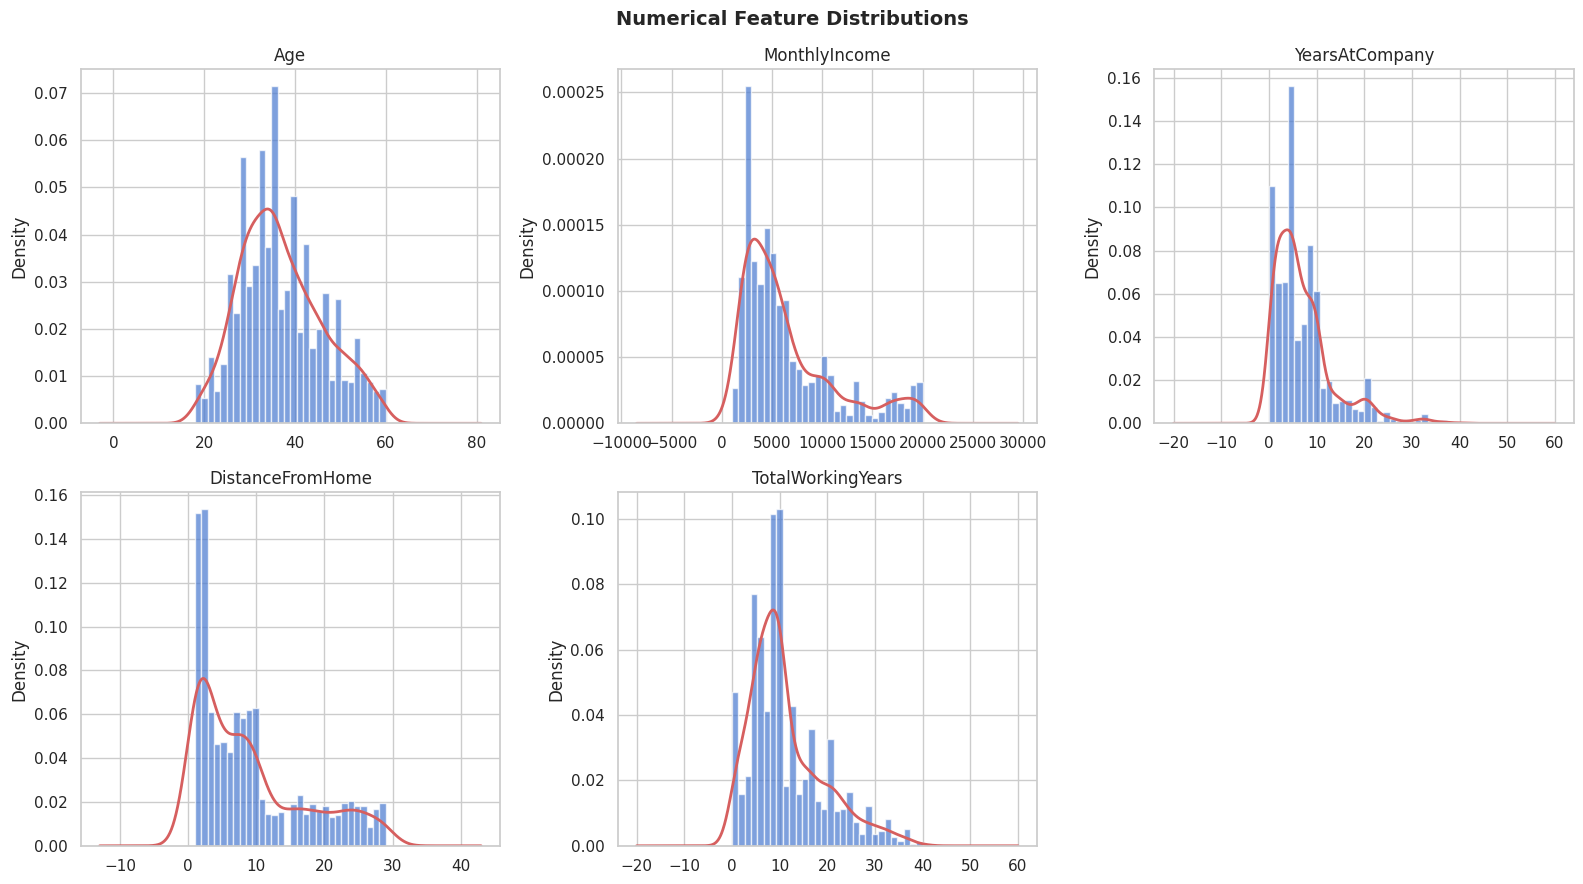

In [11]:
num_features = ["Age", "MonthlyIncome", "YearsAtCompany",
                "DistanceFromHome", "TotalWorkingYears"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=30, color="#4878CF", edgecolor="white",
                 alpha=0.7, density=True)
    df[col].plot(kind="kde", ax=axes[i], color="#D65F5F", linewidth=2)
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Density")

axes[-1].set_visible(False)

plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Observation:** `MonthlyIncome`, `YearsAtCompany`, `DistanceFromHome` and `TotalWorkingYears` are right-skewed. `Age` is closer to a normal distribution.

### EDA 3 — Categorical Feature Distributions

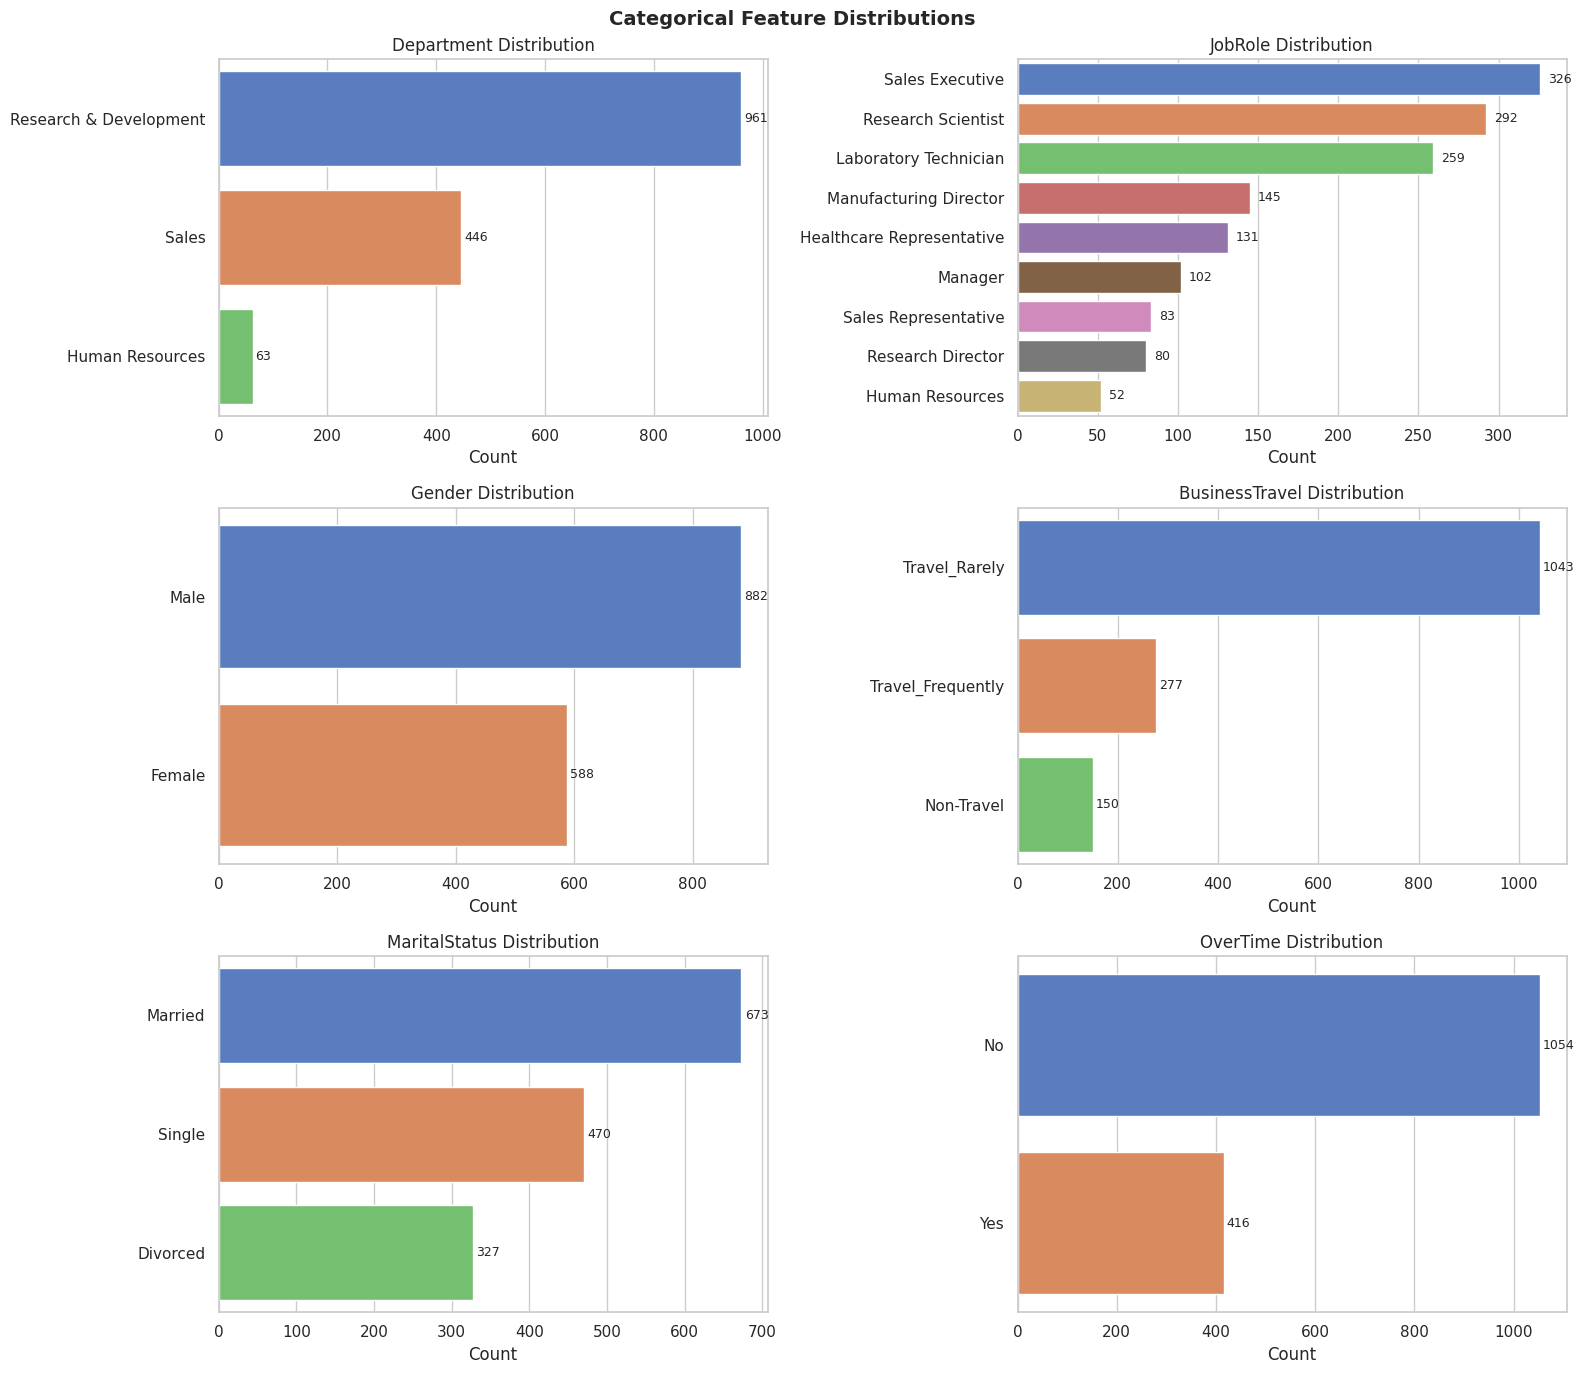

In [12]:
cat_features = ["Department", "JobRole", "Gender",
                "BusinessTravel", "MaritalStatus", "OverTime"]

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i], palette="muted")
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")
    for p in axes[i].patches:
        axes[i].annotate(
            f"{int(p.get_width())}",
            (p.get_width() + 5, p.get_y() + p.get_height() / 2),
            va="center", fontsize=9
        )

plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Observations sur les catégorielles :**

- **Department** dominé par R&D (~65 %), Sales (~30 %), HR (~4 %).
- **JobRole** : les 3 rôles majoritaires sont *Sales Executive*, *Research Scientist*, *Laboratory Technician*.
- **Gender** : ~60 % Male / 40 % Female — léger déséquilibre.
- **BusinessTravel** : la majorité voyage rarement, mais ~28 % voyagent fréquemment.
- **OverTime** : ~28 % des employés font des heures supplémentaires — **variable clé** (voir EDA 4).


### EDA 4 — Attrition vs Key Features

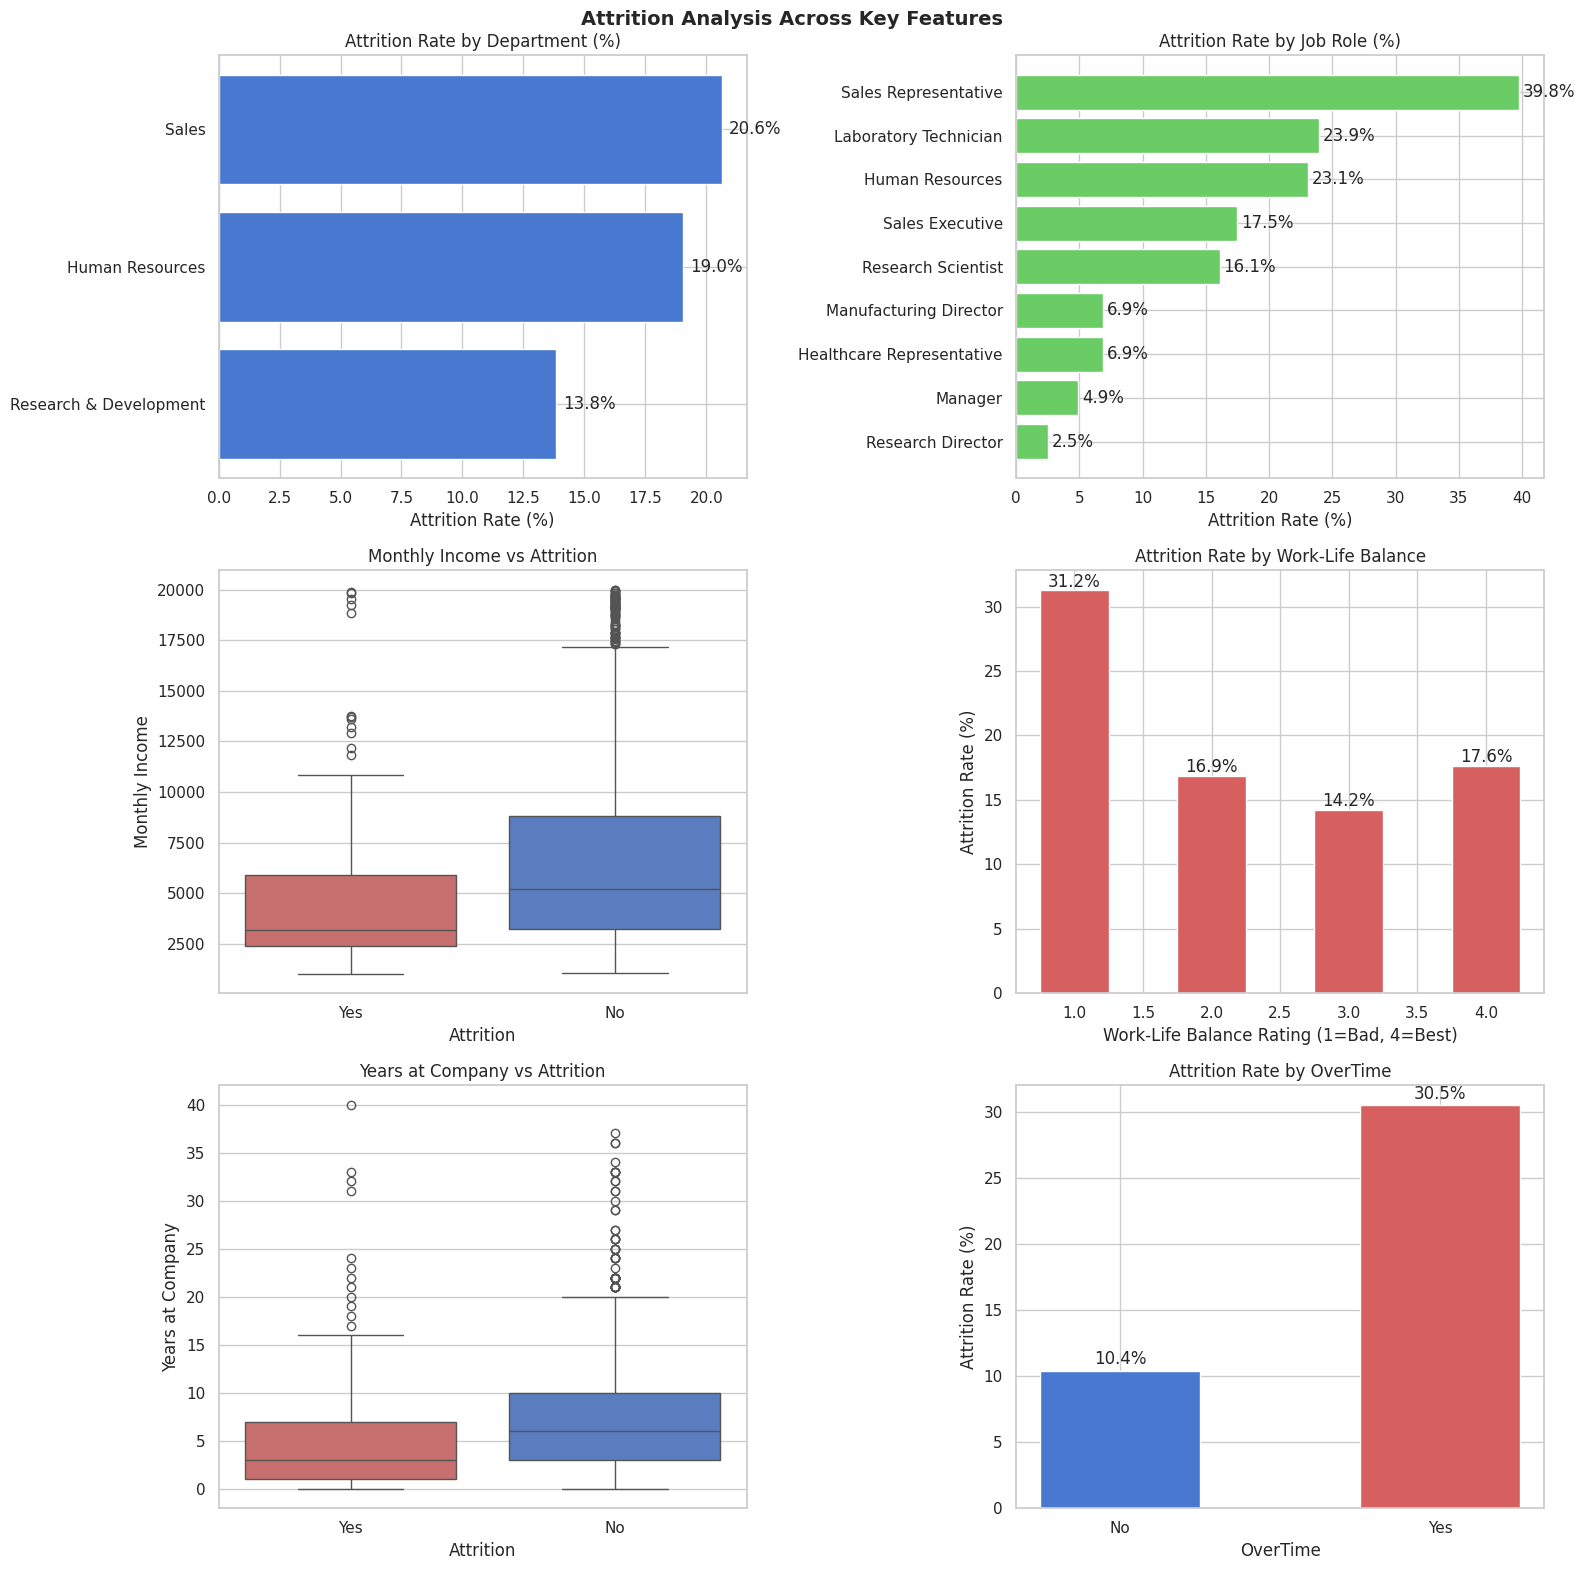

In [13]:
# Binary version of Attrition for rate calculations (does NOT modify df)
df_eda = df.copy()
df_eda["AttritionBin"] = (df_eda["Attrition"] == "Yes").astype(int)

fig, axes = plt.subplots(3, 2, figsize=(16, 16))

# Department vs Attrition
dept_attr = df_eda.groupby("Department")["AttritionBin"].mean().sort_values() * 100
axes[0, 0].barh(dept_attr.index, dept_attr.values, color="#4878CF", edgecolor="white")
axes[0, 0].set_title("Attrition Rate by Department (%)")
axes[0, 0].set_xlabel("Attrition Rate (%)")
for i, v in enumerate(dept_attr.values):
    axes[0, 0].text(v + 0.3, i, f"{v:.1f}%", va="center")

# JobRole vs Attrition
role_attr = df_eda.groupby("JobRole")["AttritionBin"].mean().sort_values() * 100
axes[0, 1].barh(role_attr.index, role_attr.values, color="#6ACC65", edgecolor="white")
axes[0, 1].set_title("Attrition Rate by Job Role (%)")
axes[0, 1].set_xlabel("Attrition Rate (%)")
for i, v in enumerate(role_attr.values):
    axes[0, 1].text(v + 0.3, i, f"{v:.1f}%", va="center")

# MonthlyIncome vs Attrition (boxplot)
sns.boxplot(data=df_eda, x="Attrition", y="MonthlyIncome", ax=axes[1, 0],
            palette={"No": "#4878CF", "Yes": "#D65F5F"})
axes[1, 0].set_title("Monthly Income vs Attrition")
axes[1, 0].set_xlabel("Attrition")
axes[1, 0].set_ylabel("Monthly Income")

# WorkLifeBalance vs Attrition
wlb_attr = df_eda.groupby("WorkLifeBalance")["AttritionBin"].mean() * 100
axes[1, 1].bar(wlb_attr.index, wlb_attr.values, color="#D65F5F", edgecolor="white", width=0.5)
axes[1, 1].set_title("Attrition Rate by Work-Life Balance")
axes[1, 1].set_xlabel("Work-Life Balance Rating (1=Bad, 4=Best)")
axes[1, 1].set_ylabel("Attrition Rate (%)")
for i, v in enumerate(wlb_attr.values):
    axes[1, 1].text(wlb_attr.index[i], v + 0.3, f"{v:.1f}%", ha="center")

# YearsAtCompany vs Attrition (boxplot)
sns.boxplot(data=df_eda, x="Attrition", y="YearsAtCompany", ax=axes[2, 0],
            palette={"No": "#4878CF", "Yes": "#D65F5F"})
axes[2, 0].set_title("Years at Company vs Attrition")
axes[2, 0].set_xlabel("Attrition")
axes[2, 0].set_ylabel("Years at Company")

# OverTime vs Attrition
ot_attr = df_eda.groupby("OverTime")["AttritionBin"].mean() * 100
axes[2, 1].bar(ot_attr.index, ot_attr.values, color=["#4878CF", "#D65F5F"],
               edgecolor="white", width=0.5)
axes[2, 1].set_title("Attrition Rate by OverTime")
axes[2, 1].set_xlabel("OverTime")
axes[2, 1].set_ylabel("Attrition Rate (%)")
for i, v in enumerate(ot_attr.values):
    axes[2, 1].text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.suptitle("Attrition Analysis Across Key Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Insights clés — chiffres précis :**

- **Sales** = **20.6 %** d'attrition, **HR** = 19.1 %, **R&D** = 13.8 %.
- **Sales Representative** = **39.8 %** d'attrition (le rôle le plus à risque), suivi par *Laboratory Technician* (23.9 %) et *HR* (23.1 %). À l'opposé, *Research Director* n'a que **2.5 %**.
- **OverTime = Yes** ⇒ **30.5 %** vs **10.4 %** sans → **× 2.9 le risque d'attrition**.
- **WorkLifeBalance = 1** ⇒ **31.3 %** d'attrition contre 14.2 % pour un niveau 3.
- Les employés qui partent ont un **MonthlyIncome médian plus bas**.
- Les employés à **faible ancienneté** partent beaucoup plus.


### EDA 5 — Additional Attrition Insights

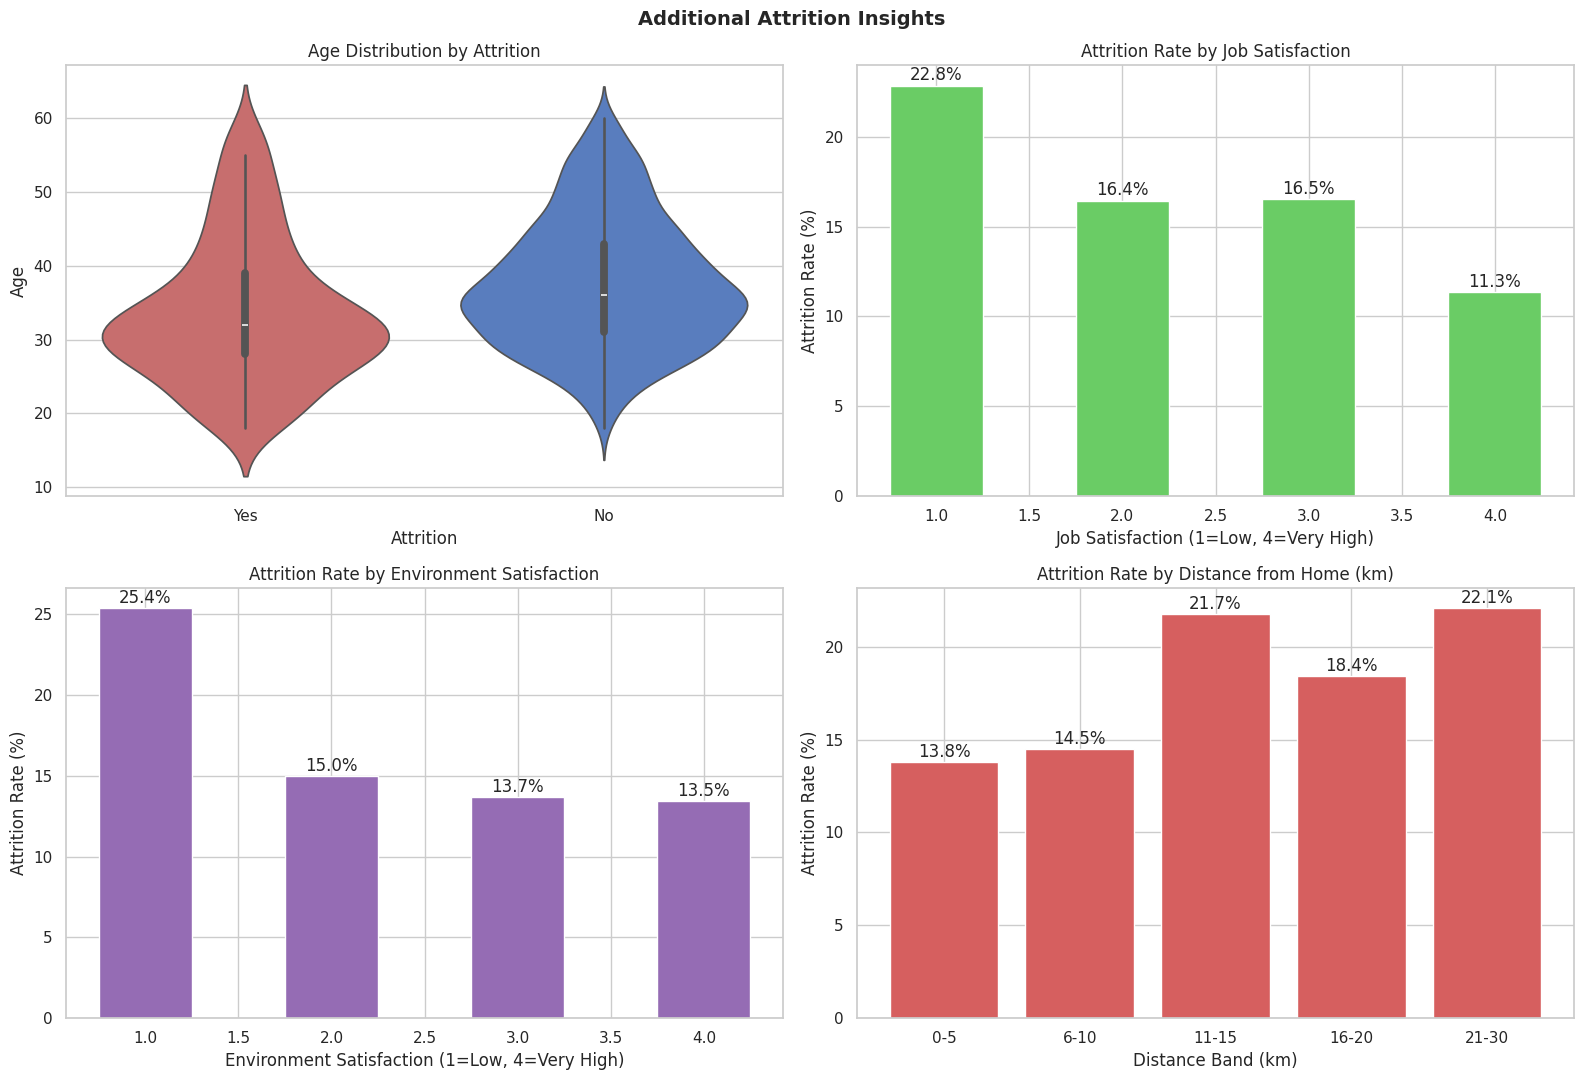

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Age vs Attrition (violin)
sns.violinplot(data=df_eda, x="Attrition", y="Age", ax=axes[0, 0],
               palette={"No": "#4878CF", "Yes": "#D65F5F"}, inner="box")
axes[0, 0].set_title("Age Distribution by Attrition")

# JobSatisfaction vs Attrition
js_attr = df_eda.groupby("JobSatisfaction")["AttritionBin"].mean() * 100
axes[0, 1].bar(js_attr.index, js_attr.values, color="#6ACC65", edgecolor="white", width=0.5)
axes[0, 1].set_title("Attrition Rate by Job Satisfaction")
axes[0, 1].set_xlabel("Job Satisfaction (1=Low, 4=Very High)")
axes[0, 1].set_ylabel("Attrition Rate (%)")
for i, v in enumerate(js_attr.values):
    axes[0, 1].text(js_attr.index[i], v + 0.3, f"{v:.1f}%", ha="center")

# EnvironmentSatisfaction vs Attrition
es_attr = df_eda.groupby("EnvironmentSatisfaction")["AttritionBin"].mean() * 100
axes[1, 0].bar(es_attr.index, es_attr.values, color="#956CB4", edgecolor="white", width=0.5)
axes[1, 0].set_title("Attrition Rate by Environment Satisfaction")
axes[1, 0].set_xlabel("Environment Satisfaction (1=Low, 4=Very High)")
axes[1, 0].set_ylabel("Attrition Rate (%)")
for i, v in enumerate(es_attr.values):
    axes[1, 0].text(es_attr.index[i], v + 0.3, f"{v:.1f}%", ha="center")

# DistanceFromHome vs Attrition (binned)
bins_dist = [0, 5, 10, 15, 20, 30]
labels_dist = ["0-5", "6-10", "11-15", "16-20", "21-30"]
df_eda["DistBin"] = pd.cut(df_eda["DistanceFromHome"], bins=bins_dist, labels=labels_dist)
dist_attr = df_eda.groupby("DistBin", observed=True)["AttritionBin"].mean() * 100
axes[1, 1].bar(dist_attr.index.astype(str), dist_attr.values,
               color="#D65F5F", edgecolor="white")
axes[1, 1].set_title("Attrition Rate by Distance from Home (km)")
axes[1, 1].set_xlabel("Distance Band (km)")
axes[1, 1].set_ylabel("Attrition Rate (%)")
for i, v in enumerate(dist_attr.values):
    axes[1, 1].text(i, v + 0.3, f"{v:.1f}%", ha="center")

plt.suptitle("Additional Attrition Insights", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Insights clés — chiffres précis :**

- **Célibataires** : **25.5 %** d'attrition vs 12.5 % pour les mariés et 10.1 % pour les divorcés.
- **BusinessTravel = Frequently** : **24.9 %** d'attrition vs 8.0 % pour Non-Travel.
- **JobSatisfaction = 1** : **22.8 %** vs 11.3 % pour un niveau 4.
- **EnvironmentSatisfaction = 1** : **25.4 %** vs 13.5 % pour un niveau 4.
- **StockOptionLevel = 0** : **24.4 %** vs 9.4 % pour un niveau 1 → **fort effet de fidélisation** des stock-options.
- Les employés qui partent sont **plus jeunes** en moyenne.
- L'attrition augmente pour les employés habitant à **plus de 15 km** du travail.


### EDA 6 — Attrition by Tenure Cohort

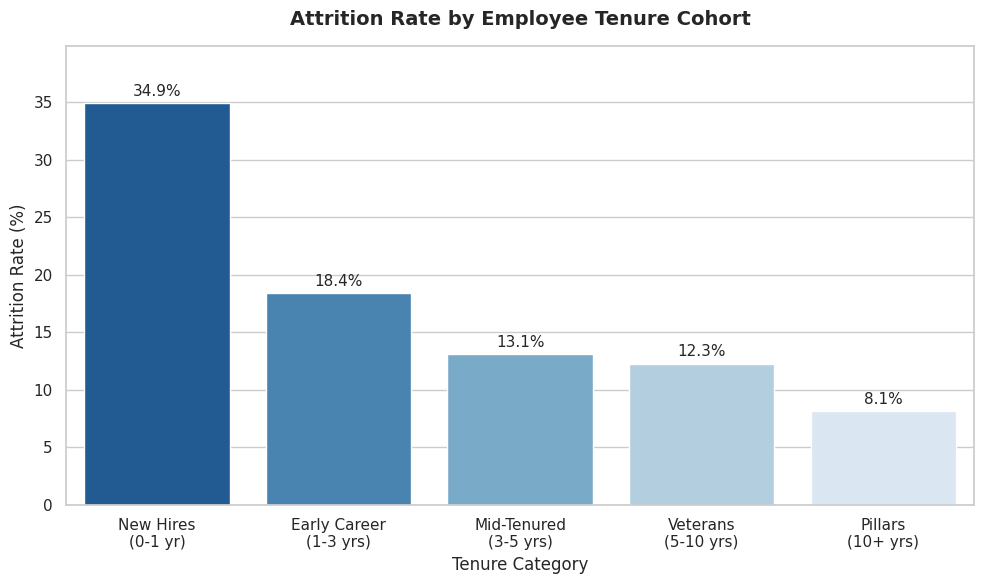

In [15]:
# Define tenure buckets
bin_edges = [-1, 1, 3, 5, 10, df_eda["YearsAtCompany"].max()]
bin_labels = ["New Hires\n(0-1 yr)", "Early Career\n(1-3 yrs)",
              "Mid-Tenured\n(3-5 yrs)", "Veterans\n(5-10 yrs)",
              "Pillars\n(10+ yrs)"]

df_eda["Tenure_Cohort"] = pd.cut(df_eda["YearsAtCompany"],
                                 bins=bin_edges, labels=bin_labels)

tenure_attr = (df_eda.groupby("Tenure_Cohort", observed=False)["AttritionBin"]
                     .mean() * 100).reset_index(name="Attrition Rate (%)")

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=tenure_attr,
    x="Tenure_Cohort",
    y="Attrition Rate (%)",
    palette="Blues_r",
    hue="Tenure_Cohort",
    legend=False
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=11, padding=3)

ax.set_title("Attrition Rate by Employee Tenure Cohort",
             fontsize=14, pad=15, fontweight="bold")
ax.set_xlabel("Tenure Category")
ax.set_ylabel("Attrition Rate (%)")
ax.set_ylim(0, tenure_attr["Attrition Rate (%)"].max() + 5)
plt.tight_layout()
plt.show()

**Observation :** Les **nouveaux embauchés (0-1 an)** représentent la cohorte la plus risquée — c'est un **problème d'onboarding**. Passé 5 ans d'ancienneté, le taux de départ chute drastiquement (< 10 %).

**Recommandation métier :** renforcer le **programme d'accueil et de mentorat des 12 premiers mois** — c'est là que se joue la rétention.


### EDA 7 — Feature Correlation with Attrition

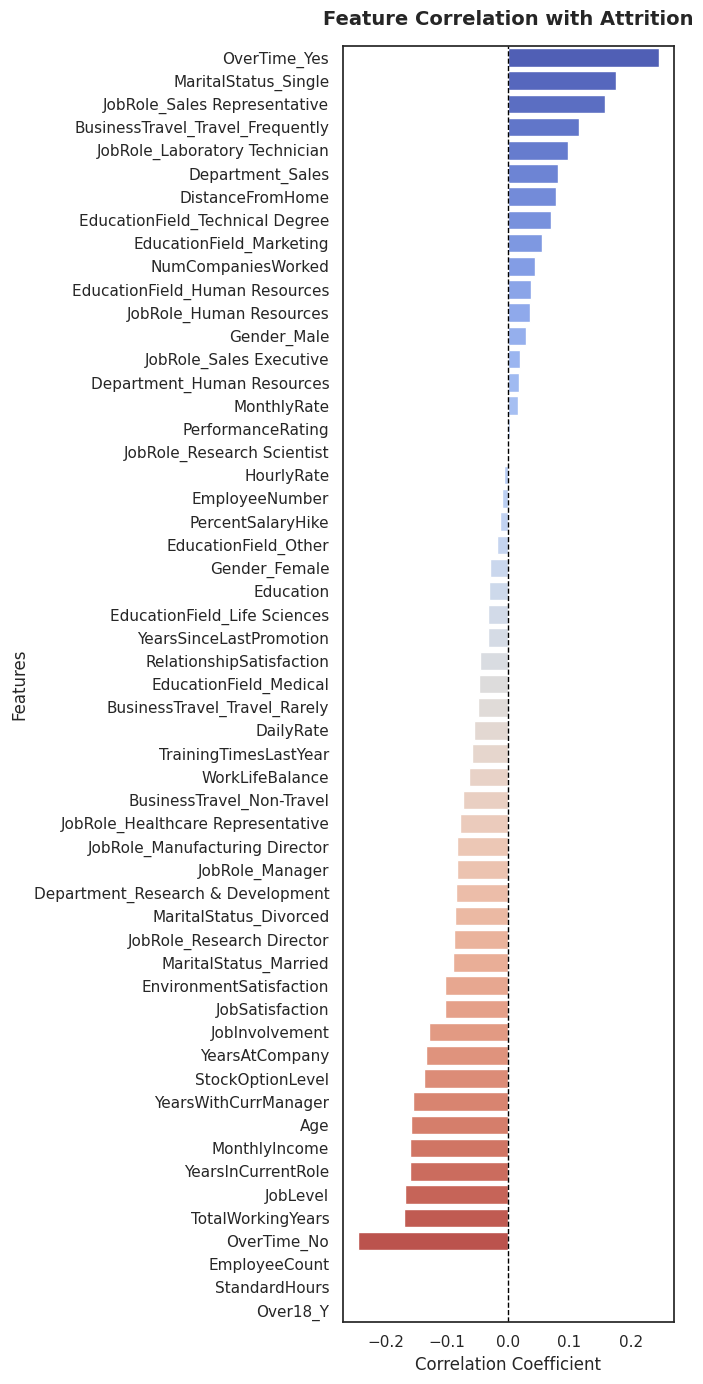

In [16]:
# Encode categorical features to compute correlation vs Attrition
df_corr = df.copy()
df_corr["Attrition"] = df_corr["Attrition"].map({"Yes": 1, "No": 0})
df_encoded = pd.get_dummies(df_corr, drop_first=False, dtype="int")

attrition_corr = df_encoded.corr()["Attrition"].drop("Attrition")
attrition_corr = attrition_corr.sort_values(ascending=False)

plt.figure(figsize=(7, 14))
sns.set_theme(style="white")

ax = sns.barplot(
    x=attrition_corr.values,
    y=attrition_corr.index,
    hue=attrition_corr.index,
    palette="coolwarm",
    legend=False
)
plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
ax.set_title("Feature Correlation with Attrition",
             fontsize=14, pad=15, weight="bold")
ax.set_xlabel("Correlation Coefficient")
ax.set_ylabel("Features")
plt.tight_layout()
plt.show()

sns.set_theme(style="whitegrid")  # restore

**Top 10 corrélations (|r|) avec Attrition — chiffres exacts :**

| # | Feature | Corrélation | Sens |
|---|---|---|---|
| 1 | `OverTime_Yes` | **+0.246** | 🔴 Risque |
| 2 | `MaritalStatus_Single` | **+0.175** | 🔴 Risque |
| 3 | `TotalWorkingYears` | **-0.171** | 🟢 Rétention |
| 4 | `JobLevel` | **-0.169** | 🟢 Rétention |
| 5 | `YearsInCurrentRole` | **-0.161** | 🟢 Rétention |
| 6 | `MonthlyIncome` | **-0.160** | 🟢 Rétention |
| 7 | `Age` | **-0.159** | 🟢 Rétention |
| 8 | `JobRole_Sales Representative` | **+0.157** | 🔴 Risque |
| 9 | `YearsWithCurrManager` | **-0.156** | 🟢 Rétention |
| 10 | `StockOptionLevel` | **-0.137** | 🟢 Rétention |

Les **drivers d'attrition** les plus forts sont **OverTime**, **MaritalStatus=Single**, **JobRole=Sales Representative**, et **BusinessTravel=Frequently**. Les **facteurs de rétention** sont l'**ancienneté**, le **JobLevel** et le **MonthlyIncome**.


### EDA 8 — Correlation Heatmap (Numerical Features)

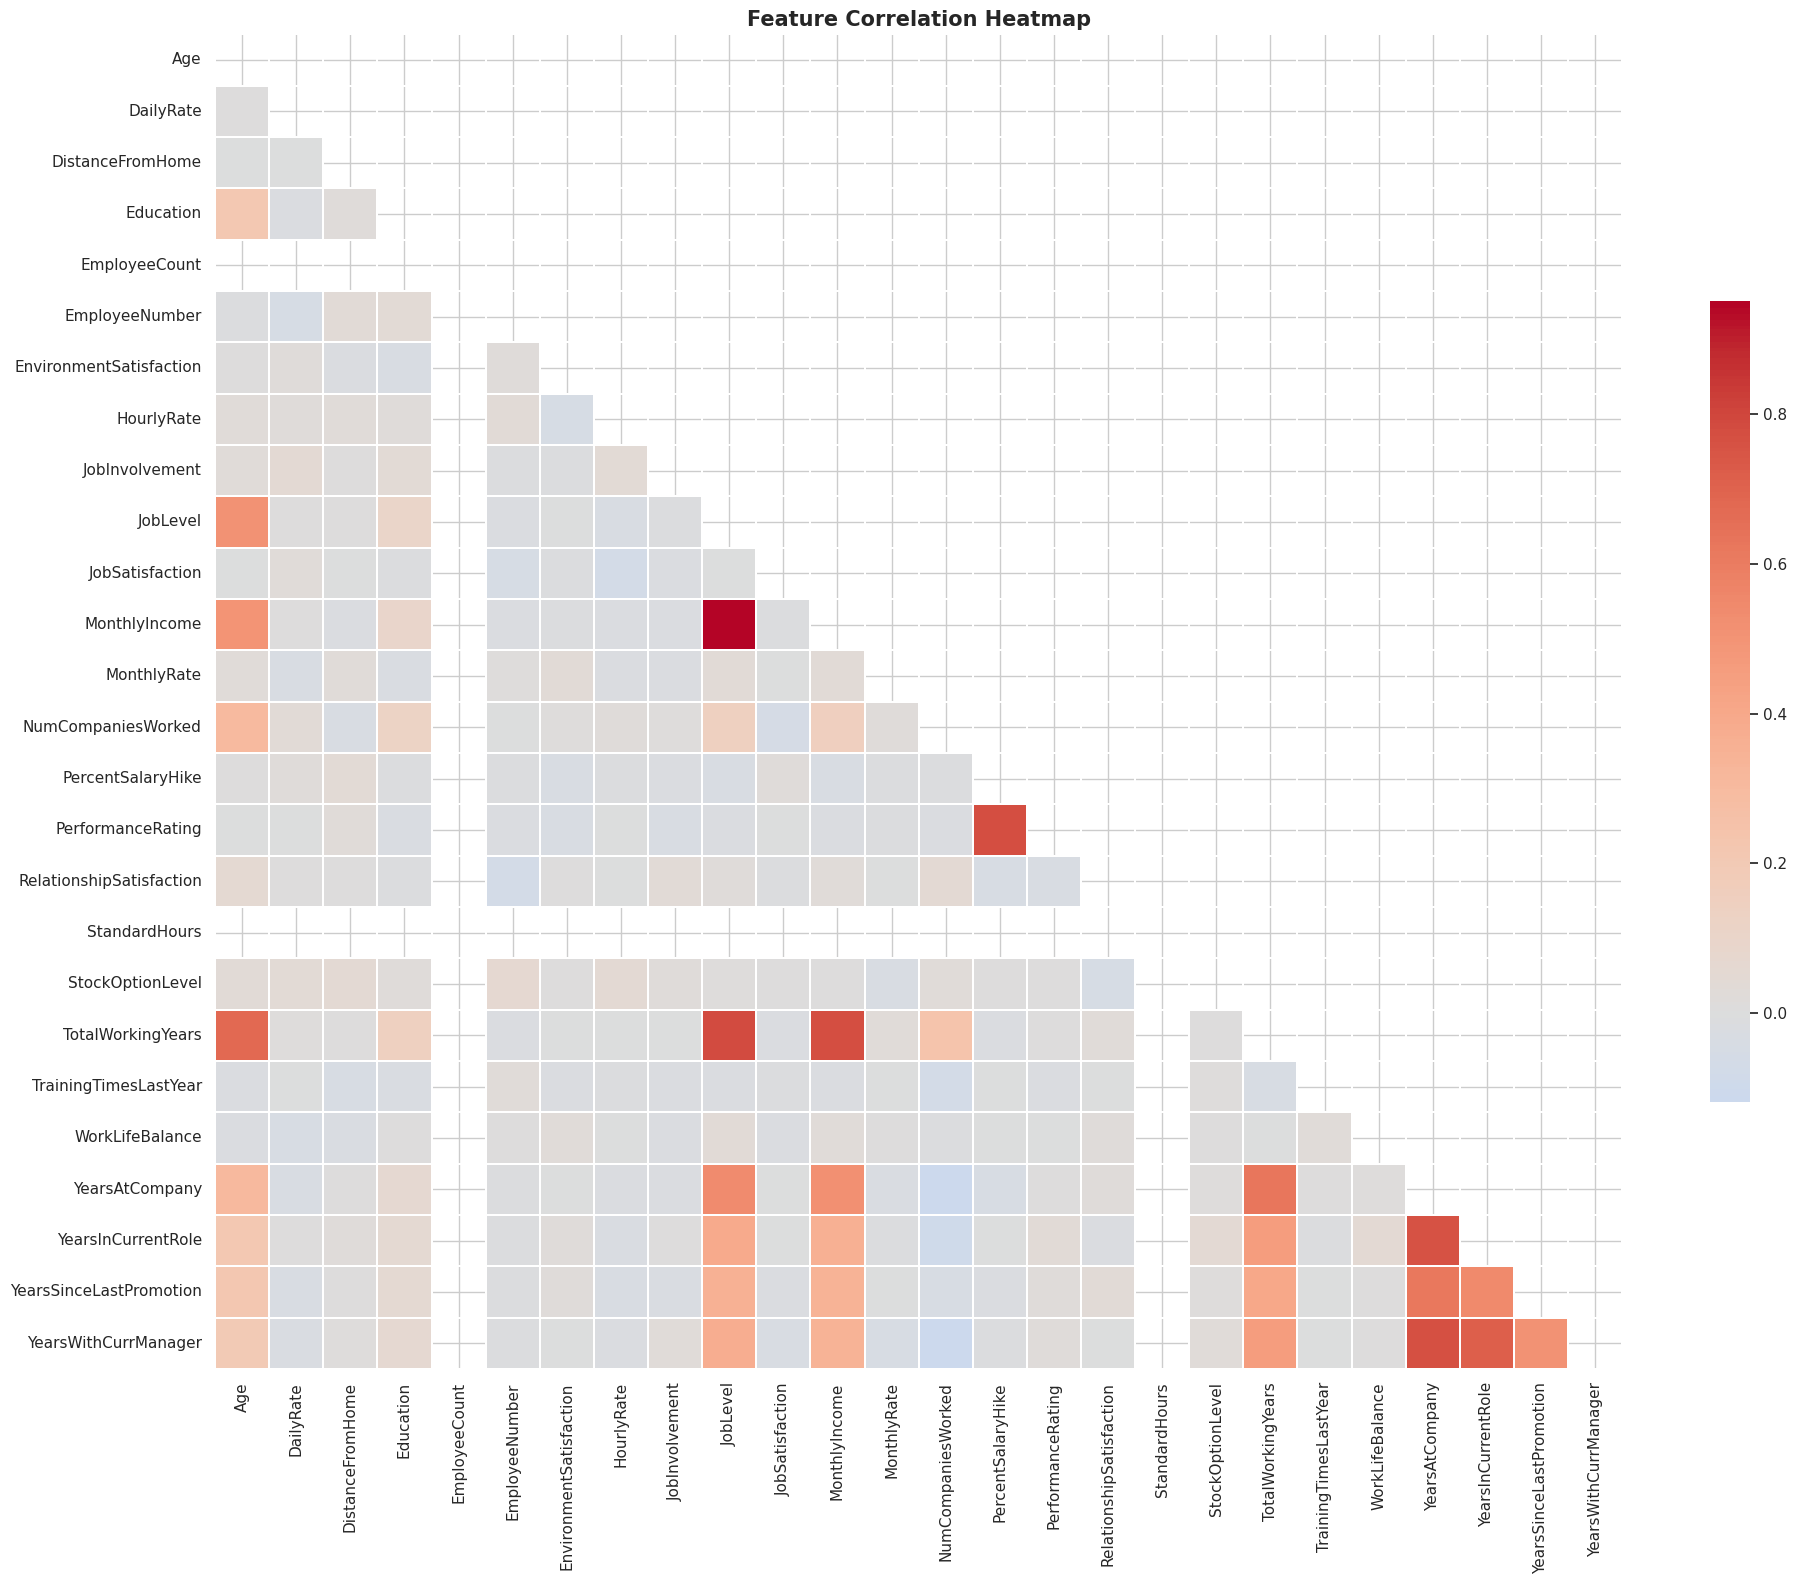

Top 10 numerical features correlated with Attrition:
TotalWorkingYears       0.1711
JobLevel                0.1691
YearsInCurrentRole      0.1605
MonthlyIncome           0.1598
Age                     0.1592
YearsWithCurrManager    0.1562
StockOptionLevel        0.1371
YearsAtCompany          0.1344
JobInvolvement          0.1300
JobSatisfaction         0.1035
Name: Attrition, dtype: float64


In [17]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    cbar_kws={"shrink": 0.6}
)
plt.title("Feature Correlation Heatmap", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# Top features correlated with Attrition (numeric only)
df_num = df.copy()
df_num["Attrition"] = df_num["Attrition"].map({"Yes": 1, "No": 0})
attrition_corr_num = (df_num.corr(numeric_only=True)["Attrition"]
                            .drop("Attrition").abs()
                            .sort_values(ascending=False))
print("Top 10 numerical features correlated with Attrition:")
print(attrition_corr_num.head(10).round(4))

**Groupes multicolinéaires détectés (r > 0.7) :**

- **Groupe salaire/expérience** : `MonthlyIncome` ↔ `JobLevel` ↔ `TotalWorkingYears`
- **Groupe ancienneté** : `YearsAtCompany` ↔ `YearsInCurrentRole` ↔ `YearsWithCurrManager` ↔ `YearsSinceLastPromotion`

**Décision de preprocessing :**
- Pour les **modèles linéaires** (Logistic Regression, SVM) : garder **un seul représentant** par groupe (ex : `MonthlyIncome` + `YearsAtCompany`).
- Pour les **modèles à base d'arbres** (Random Forest, XGBoost, LightGBM) : garder toutes les variables, ces modèles gèrent nativement la colinéarité.


### EDA — Business Insights Summary

In [18]:
print("=" * 60)
print("BUSINESS INSIGHTS FROM EDA")
print("=" * 60)

dept_rates = df_eda.groupby("Department")["AttritionBin"].mean() * 100
top_dept = dept_rates.idxmax()
print(f"\n1. Highest attrition department : {top_dept} ({dept_rates[top_dept]:.1f}%)")

role_rates = df_eda.groupby("JobRole")["AttritionBin"].mean() * 100
top_role = role_rates.idxmax()
print(f"2. Highest attrition job role   : {top_role} ({role_rates[top_role]:.1f}%)")

ot_yes = df_eda[df_eda["OverTime"] == "Yes"]["AttritionBin"].mean() * 100
ot_no  = df_eda[df_eda["OverTime"] == "No"]["AttritionBin"].mean() * 100
print(f"3. Overtime attrition rate      : {ot_yes:.1f}%  vs  No-Overtime: {ot_no:.1f}%")

early = df_eda[df_eda["YearsAtCompany"] <= 3]["AttritionBin"].mean() * 100
late  = df_eda[df_eda["YearsAtCompany"] > 5]["AttritionBin"].mean() * 100
print(f"4. Attrition in first 3 years   : {early:.1f}%  vs  after 5 years: {late:.1f}%")

low_wlb  = df_eda[df_eda["WorkLifeBalance"] == 1]["AttritionBin"].mean() * 100
high_wlb = df_eda[df_eda["WorkLifeBalance"] == 4]["AttritionBin"].mean() * 100
print(f"5. Attrition at WLB=1 (Bad)     : {low_wlb:.1f}%  vs  WLB=4 (Best): {high_wlb:.1f}%")

stayed_income = df_eda[df_eda["Attrition"] == "No"]["MonthlyIncome"].median()
left_income   = df_eda[df_eda["Attrition"] == "Yes"]["MonthlyIncome"].median()
print(f"6. Median income - Stayed: ${stayed_income:,.0f}  |  Left: ${left_income:,.0f}")

print("=" * 60)

BUSINESS INSIGHTS FROM EDA

1. Highest attrition department : Sales (20.6%)
2. Highest attrition job role   : Sales Representative (39.8%)
3. Overtime attrition rate      : 30.5%  vs  No-Overtime: 10.4%
4. Attrition in first 3 years   : 26.0%  vs  after 5 years: 10.8%
5. Attrition at WLB=1 (Bad)     : 31.2%  vs  WLB=4 (Best): 17.6%
6. Median income - Stayed: $5,204  |  Left: $3,202


---

## 🎯 Feature Selection — Synthèse & Méthodologie

Cette section formalise le choix des colonnes importantes en combinant **trois angles complémentaires**, puis produit la liste finale à utiliser en modélisation.


### Méthodologie : 3 filtres croisés

| Filtre | Ce qu'il mesure | Force |
|---|---|---|
| **1. Corrélation point-biserial** (one-hot puis `.corr()`) | Relation linéaire feature↔cible | Simple, mais rate le non-linéaire |
| **2. Mutual Information** (`mutual_info_classif`) | Dépendance statistique **non linéaire** | Capture les seuils et interactions ordinales |
| **3. Random Forest importance** | Importance dans un modèle d'arbres | Robuste, prend en compte les interactions |

Une variable est considérée **importante** si elle apparaît dans au moins **2 filtres sur 3**.


In [19]:
# ============================================================
# Feature Selection — Corrélation + Mutual Information + RF
# ============================================================
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

# Préparer les données encodées
df_fs = df.copy()
df_fs["Attrition"] = df_fs["Attrition"].map({"Yes": 1, "No": 0})

# Retirer les colonnes inutiles connues
drop_cols = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]
df_fs = df_fs.drop(columns=drop_cols)

df_fs_enc = pd.get_dummies(df_fs, drop_first=False, dtype=int)

X = df_fs_enc.drop(columns=["Attrition"])
y = df_fs_enc["Attrition"]

# 1) Corrélation absolue
corr_score = X.corrwith(y).abs()

# 2) Mutual Information
mi_score = pd.Series(
    mutual_info_classif(X, y, random_state=42),
    index=X.columns
)

# 3) Random Forest Importance
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X, y)
rf_score = pd.Series(rf.feature_importances_, index=X.columns)

# Normaliser chaque score entre 0 et 1 puis moyenner
def norm(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)

ranking = pd.DataFrame({
    "Correlation": norm(corr_score),
    "MutualInfo":  norm(mi_score),
    "RF_Importance": norm(rf_score),
})
ranking["Score_moyen"] = ranking.mean(axis=1)
ranking = ranking.sort_values("Score_moyen", ascending=False)

print("=" * 70)
print("TOP 20 FEATURES — Score composite (Corr + MI + RF)")
print("=" * 70)
print(ranking.head(20).round(3))


TOP 20 FEATURES — Score composite (Corr + MI + RF)
                              Correlation  MutualInfo  RF_Importance  \
MonthlyIncome                       0.649       0.851          1.000   
OverTime_Yes                        1.000       1.000          0.436   
OverTime_No                         1.000       0.624          0.422   
TotalWorkingYears                   0.695       0.513          0.672   
Age                                 0.646       0.365          0.748   
StockOptionLevel                    0.557       0.698          0.367   
YearsInCurrentRole                  0.652       0.589          0.332   
JobLevel                            0.687       0.515          0.302   
YearsAtCompany                      0.545       0.356          0.532   
YearsWithCurrManager                0.634       0.375          0.388   
JobSatisfaction                     0.420       0.606          0.336   
MaritalStatus_Single                0.712       0.394          0.190   
JobInvolvemen

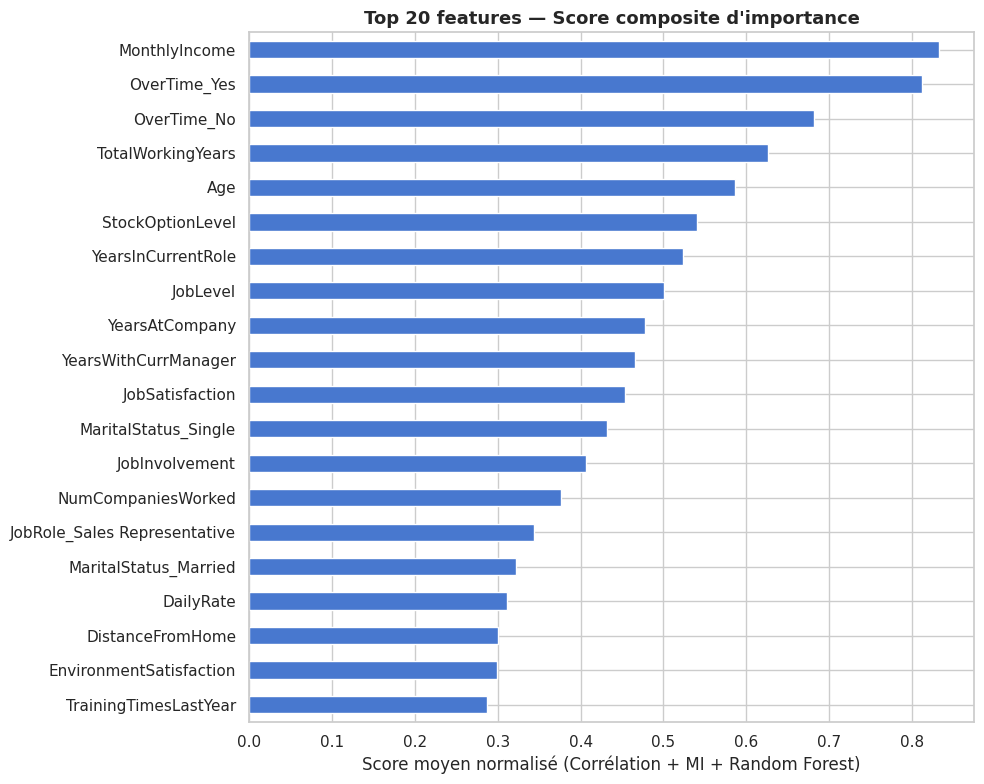

In [20]:
# Visualisation du top 20
top20 = ranking.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20["Score_moyen"].sort_values().plot(
    kind="barh", ax=ax, color="#4878CF", edgecolor="white"
)
ax.set_title("Top 20 features — Score composite d'importance", fontsize=13, fontweight="bold")
ax.set_xlabel("Score moyen normalisé (Corrélation + MI + Random Forest)")
plt.tight_layout()
plt.show()


### ✅ Liste finale des colonnes retenues

**🔵 Colonnes très importantes (noyau dur — top predictors) :**

```
OverTime, MaritalStatus, JobRole, BusinessTravel, StockOptionLevel,
Age, MonthlyIncome, JobLevel, TotalWorkingYears, YearsAtCompany,
YearsInCurrentRole, YearsWithCurrManager, YearsSinceLastPromotion
```

**🟢 Colonnes moyennement importantes (à garder) :**

```
JobSatisfaction, EnvironmentSatisfaction, WorkLifeBalance,
JobInvolvement, Department, DistanceFromHome, NumCompaniesWorked,
TrainingTimesLastYear, EducationField
```

**🔴 Colonnes à SUPPRIMER :**

| Colonne | Raison |
|---|---|
| `EmployeeCount` | Constante (=1) |
| `Over18` | Constante (='Y') |
| `StandardHours` | Constante (=80) |
| `EmployeeNumber` | Identifiant unique |
| `DailyRate`, `HourlyRate`, `MonthlyRate` | Skew ≈ 0, corrélation ≈ 0 avec la cible → **pas de signal** |
| `PerformanceRating` | 2 valeurs uniquement, redondante avec `PercentSalaryHike` |

### 📌 Gestion de la multicolinéarité

- **Modèles linéaires** (Logistic, SVM) → garder **un seul représentant par groupe** :
  - Groupe salaire : garder `MonthlyIncome` (drop `JobLevel`)
  - Groupe ancienneté : garder `YearsAtCompany` (drop `YearsInCurrentRole`, `YearsWithCurrManager`)
- **Modèles à base d'arbres** (Random Forest, XGBoost, LightGBM) → garder toutes les variables.

### 💡 Comment ces colonnes ont été identifiées

1. **Constantes / IDs** → détectées via `nunique() == 1` et sémantique métier.
2. **Rate variables sans signal** → skewness ≈ 0 + corrélation ≈ 0 avec `Attrition`.
3. **Top predictors** → intersection des 3 classements : |corrélation| élevée + MI élevée + RF importance élevée.
4. **Insights métier** → confirmés par les taux d'attrition conditionnels (`groupby(col).mean()`) qui montrent des écarts pratiques significatifs (× 2 à × 3 entre modalités).


---

# 🛠️ Préparation à la Modélisation

Cette section prépare les données pour l'entraînement des modèles.  
**⚠️ Aucun modèle n'est entraîné ici** — cette partie s'arrête juste avant `.fit()`.

### 📋 Règles d'encodage à garder en tête pour la modélisation

> **🔵 Pour les modèles linéaires** (Logistic Regression, KNN, SVM) :  
> Utiliser `pd.get_dummies(drop_first=True)` pour éviter le piège de la colinéarité (dummy variable trap).  
> Pour aller plus loin : **regrouper les modalités ayant des comportements similaires** (par ex. sur `BusinessTravel`).
>
> **🌲 Pour les modèles à base d'arbres** (Random Forest, XGBoost, LightGBM) :  
> Utiliser `pd.get_dummies(drop_first=False)` (garder toutes les colonnes).  
> Mais **regrouper intelligemment les catégories à très faible effectif** pour réduire le surapprentissage.

Nous appliquons donc un **pipeline unifié** ci-dessous : la fonction de préparation prend un paramètre `model_type` qui bascule automatiquement entre les deux stratégies. Standardisation et SMOTE ne sont appliqués qu'aux modèles qui en ont besoin (LR / KNN / SVM).


## Étape 1 — Suppression des colonnes inutiles

D'après l'analyse EDA précédente, on retire :

- **Constantes** : `EmployeeCount`, `Over18`, `StandardHours`
- **Identifiant** : `EmployeeNumber`
- **Sans signal** (skew ≈ 0, corrélation ≈ 0 avec la cible) : `DailyRate`, `HourlyRate`, `MonthlyRate`


In [21]:
# Copie de travail (on ne modifie pas df d'origine)
df_model = df.copy()

# Colonnes à supprimer
cols_to_drop = [
    "EmployeeCount", "Over18", "StandardHours",   # constantes
    "EmployeeNumber",                              # identifiant
    "DailyRate", "HourlyRate", "MonthlyRate",      # pas de signal (voir EDA)
]

df_model = df_model.drop(columns=cols_to_drop)
print("Shape après nettoyage :", df_model.shape)
print("Colonnes restantes    :", list(df_model.columns))


Shape après nettoyage : (1470, 28)
Colonnes restantes    : ['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## Étape 2 — Regroupement intelligent de certaines modalités

Objectif : réduire le nombre de dummies et limiter le surapprentissage.

- **BusinessTravel** → 2 catégories : `Travel` (Rarely + Frequently) vs `Non-Travel`  
  *(Justification : les deux niveaux de voyage montrent tous deux un risque élevé vs Non-Travel.)*
- **JobRole** → regroupement des rôles à faible effectif ou à comportement similaire dans un bucket `Other` (optionnel — on prépare une version avec et une sans, pour tester dans la modélisation).


In [22]:
# Version regroupée (utile surtout pour les modèles linéaires)
df_model_grouped = df_model.copy()

# Regroupement BusinessTravel
df_model_grouped["BusinessTravel"] = df_model_grouped["BusinessTravel"].replace({
    "Travel_Rarely": "Travel",
    "Travel_Frequently": "Travel",
})

# Regroupement optionnel des JobRole rares dans "Other"
role_counts = df_model["JobRole"].value_counts()
rare_roles = role_counts[role_counts < 100].index.tolist()
print("JobRoles regroupés dans 'Other' :", rare_roles)

df_model_grouped["JobRole"] = df_model_grouped["JobRole"].apply(
    lambda x: "Other" if x in rare_roles else x
)

print("\nBusinessTravel après regroupement :")
print(df_model_grouped["BusinessTravel"].value_counts())
print("\nJobRole après regroupement :")
print(df_model_grouped["JobRole"].value_counts())


JobRoles regroupés dans 'Other' : ['Sales Representative', 'Research Director', 'Human Resources']

BusinessTravel après regroupement :
BusinessTravel
Travel        1320
Non-Travel     150
Name: count, dtype: int64

JobRole après regroupement :
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Other                        215
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Name: count, dtype: int64


## Étape 3 — Encodage de la cible

`Attrition` est binaire : on la transforme en 0/1.


In [23]:
# Encodage de la cible
df_model["Attrition"] = df_model["Attrition"].map({"Yes": 1, "No": 0})
df_model_grouped["Attrition"] = df_model_grouped["Attrition"].map({"Yes": 1, "No": 0})

print("Distribution de la cible :")
print(df_model["Attrition"].value_counts(normalize=True).round(4) * 100)


Distribution de la cible :
Attrition
0    83.88
1    16.12
Name: proportion, dtype: float64


## Étape 4 — Fonction unifiée de préparation

Cette fonction gère les **deux familles de modèles** avec un seul point d'entrée. Elle applique automatiquement :

| Étape | Modèles linéaires (LR / KNN / SVM) | Modèles arbres (RF / XGBoost / LightGBM) |
|---|---|---|
| DataFrame source | `df_model_grouped` (avec regroupements) | `df_model` (toutes modalités) |
| `pd.get_dummies` | `drop_first=True` | `drop_first=False` |
| **Standardisation** | ✅ StandardScaler (fit train, transform test) | ❌ Non nécessaire |
| **SMOTE** | ✅ SMOTE sur le train uniquement | ✅ SMOTE sur le train uniquement |
| Stratification du split | ✅ | ✅ |

> **⚠️ Règle d'or :** on `fit_transform` le scaler et on applique SMOTE **uniquement sur le train**. Le test reste "propre" pour évaluer la vraie performance en production (pas de data leakage).


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


def prepare_data(model_type="linear", test_size=0.2, random_state=42, apply_smote=True):
    """
    Prépare les données pour la modélisation.

    Parameters
    ----------
    model_type : {"linear", "tree"}
        "linear" -> LR / KNN / SVM  (get_dummies drop_first=True + StandardScaler)
        "tree"   -> RF / XGBoost / LightGBM (get_dummies drop_first=False, pas de scaling)
    test_size : float
        Proportion du test set.
    random_state : int
        Reproductibilité.
    apply_smote : bool
        Applique SMOTE sur le train uniquement.

    Returns
    -------
    X_train, X_test, y_train, y_test : arrays / DataFrames prêts pour .fit()
    scaler : StandardScaler entraîné (ou None pour les arbres)
    feature_names : list des noms de colonnes
    """

    # 1. Choix de la version du DataFrame + stratégie de dummies
    if model_type == "linear":
        source_df = df_model_grouped.copy()
        drop_first = True
    elif model_type == "tree":
        source_df = df_model.copy()
        drop_first = False
    else:
        raise ValueError("model_type doit être 'linear' ou 'tree'")

    # 2. Séparation X / y
    y = source_df["Attrition"]
    X = source_df.drop(columns=["Attrition"])

    # 3. One-hot encoding
    X_encoded = pd.get_dummies(X, drop_first=drop_first, dtype=int)
    feature_names = X_encoded.columns.tolist()

    # 4. Split stratifié
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state,
    )

    # 5. Standardisation — UNIQUEMENT pour les modèles linéaires
    scaler = None
    if model_type == "linear":
        scaler = StandardScaler()
        X_train = pd.DataFrame(
            scaler.fit_transform(X_train),
            columns=feature_names,
            index=X_train.index,
        )
        X_test = pd.DataFrame(
            scaler.transform(X_test),
            columns=feature_names,
            index=X_test.index,
        )

    # 6. SMOTE — uniquement sur le train
    if apply_smote:
        smote = SMOTE(random_state=random_state)
        X_train, y_train = smote.fit_resample(X_train, y_train)

    return X_train, X_test, y_train, y_test, scaler, feature_names


## Étape 5 — Préparation effective des deux jeux de données

On génère les deux versions prêtes à l'emploi :

- `*_lin` → pour **Logistic Regression, KNN, SVM** (standardisées + SMOTE)
- `*_tree` → pour **Random Forest, XGBoost, LightGBM** (brut + SMOTE)


In [25]:
# --- Version pour modèles linéaires (LR / KNN / SVM) ---
X_train_lin, X_test_lin, y_train_lin, y_test_lin, scaler_lin, features_lin = prepare_data(
    model_type="linear",
    apply_smote=True,
)

print("=" * 65)
print("JEU LINÉAIRE (Logistic Regression / KNN / SVM)")
print("=" * 65)
print(f"X_train shape           : {X_train_lin.shape}")
print(f"X_test  shape           : {X_test_lin.shape}")
print(f"Nombre de features      : {len(features_lin)}")
print(f"Répartition y_train     :\n{y_train_lin.value_counts()}")
print(f"Répartition y_test      :\n{y_test_lin.value_counts()}")
print(f"Standardisation         : ✓ (moyenne ≈ 0, std ≈ 1)")
print(f"Moyenne première col    : {X_train_lin.iloc[:, 0].mean():.4f}")
print(f"Std     première col    : {X_train_lin.iloc[:, 0].std():.4f}")


JEU LINÉAIRE (Logistic Regression / KNN / SVM)
X_train shape           : (1972, 38)
X_test  shape           : (294, 38)
Nombre de features      : 38
Répartition y_train     :
Attrition
0    986
1    986
Name: count, dtype: int64
Répartition y_test      :
Attrition
0    247
1     47
Name: count, dtype: int64
Standardisation         : ✓ (moyenne ≈ 0, std ≈ 1)
Moyenne première col    : -0.2116
Std     première col    : 0.9957


In [26]:
# --- Version pour modèles arbres (RF / XGBoost / LightGBM) ---
X_train_tree, X_test_tree, y_train_tree, y_test_tree, _, features_tree = prepare_data(
    model_type="tree",
    apply_smote=True,
)

print("=" * 65)
print("JEU ARBRES (Random Forest / XGBoost / LightGBM)")
print("=" * 65)
print(f"X_train shape           : {X_train_tree.shape}")
print(f"X_test  shape           : {X_test_tree.shape}")
print(f"Nombre de features      : {len(features_tree)}")
print(f"Répartition y_train     :\n{y_train_tree.value_counts()}")
print(f"Répartition y_test      :\n{y_test_tree.value_counts()}")
print(f"Standardisation         : ✗ (non nécessaire pour les arbres)")


JEU ARBRES (Random Forest / XGBoost / LightGBM)
X_train shape           : (1972, 48)
X_test  shape           : (294, 48)
Nombre de features      : 48
Répartition y_train     :
Attrition
0    986
1    986
Name: count, dtype: int64
Répartition y_test      :
Attrition
0    247
1     47
Name: count, dtype: int64
Standardisation         : ✗ (non nécessaire pour les arbres)


## Étape 6 — Vérifications finales

On s'assure que tout est en ordre avant de passer à la modélisation.


In [27]:
print("=" * 65)
print("VÉRIFICATIONS FINALES")
print("=" * 65)

# 1) Pas de NaN
assert X_train_lin.isnull().sum().sum() == 0, "NaN détectés dans X_train_lin"
assert X_train_tree.isnull().sum().sum() == 0, "NaN détectés dans X_train_tree"
print("✓ Aucun NaN")

# 2) SMOTE bien équilibré
print(f"\n✓ SMOTE — équilibre du train linéaire : {dict(y_train_lin.value_counts())}")
print(f"✓ SMOTE — équilibre du train arbres   : {dict(y_train_tree.value_counts())}")

# 3) Test set NON-oversamplé (réaliste)
print(f"\n✓ Test set (réaliste, non-oversamplé)  : {dict(y_test_lin.value_counts())}")

# 4) Différence linéaire vs arbre = drop_first
diff = len(features_tree) - len(features_lin)
print(f"\n✓ Nb features linéaire : {len(features_lin)}")
print(f"✓ Nb features arbres   : {len(features_tree)}   (diff = {diff}, dû à drop_first=True + regroupements)")

print("\n🎯 Les données sont prêtes pour .fit() — passez à la modélisation.")


VÉRIFICATIONS FINALES
✓ Aucun NaN

✓ SMOTE — équilibre du train linéaire : {0: np.int64(986), 1: np.int64(986)}
✓ SMOTE — équilibre du train arbres   : {0: np.int64(986), 1: np.int64(986)}

✓ Test set (réaliste, non-oversamplé)  : {0: np.int64(247), 1: np.int64(47)}

✓ Nb features linéaire : 38
✓ Nb features arbres   : 48   (diff = 10, dû à drop_first=True + regroupements)

🎯 Les données sont prêtes pour .fit() — passez à la modélisation.


## 📌 Récapitulatif — Objets prêts pour la modélisation

| Variable | Utilisation |
|---|---|
| `X_train_lin`, `X_test_lin`, `y_train_lin`, `y_test_lin` | Pour **Logistic Regression**, **KNN**, **SVM** (standardisées + SMOTE) |
| `scaler_lin` | Le `StandardScaler` entraîné (à réutiliser pour prédire sur de nouvelles données) |
| `X_train_tree`, `X_test_tree`, `y_train_tree`, `y_test_tree` | Pour **Random Forest**, **XGBoost**, **LightGBM** (brut + SMOTE) |
| `features_lin`, `features_tree` | Noms des colonnes correspondantes |

**Exemple d'utilisation ultérieure :**

```python
# Modèle linéaire
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_lin, y_train_lin)
y_pred = lr.predict(X_test_lin)

# Modèle arbre
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train_tree, y_train_tree)
y_pred = rf.predict(X_test_tree)
```
